# Convolutions
---

This notebook is a playground for convolutions and image filters with Numpy and OpenCV.

In [1]:
from glob import glob
from random import random

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
file_name = None
# file_name = '../data/misc/4.2.03.tiff'  # Uncomment to use a specific file
if not file_name:
    files = glob('../data/misc/*.tiff')
    file_name = files[int(random() * len(files))]
print(f"Using file: {file_name}")

Using file: ../data/misc/4.1.01.tiff


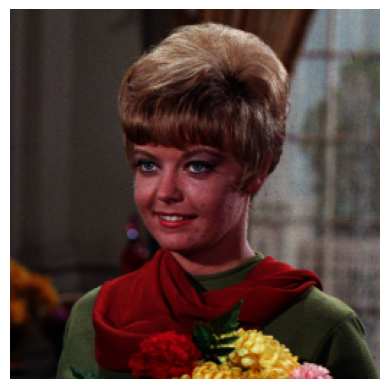

In [7]:
image = cv2.imread(file_name, cv2.IMREAD_COLOR_RGB)
plt.imshow(image)
plt.axis("off")
plt.show()

## Kernels as filters

### Blurring

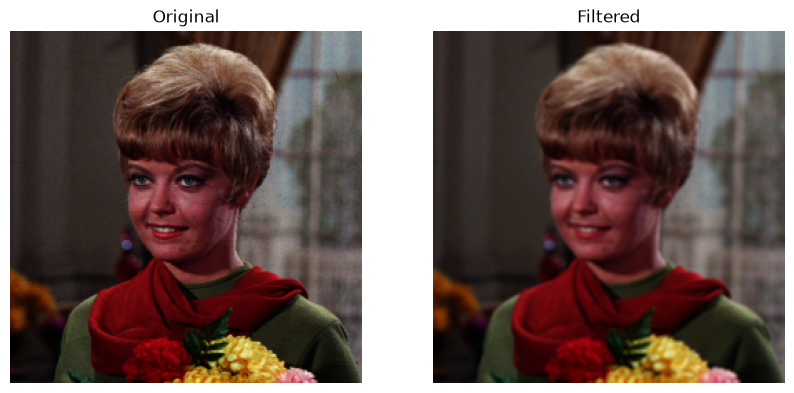

In [10]:
k = np.ones((3, 3), np.float32) / 9
image_filt = cv2.filter2D(image, -1, k)
fix, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image)
axs[0].set_title("Original")
axs[0].axis("off")
axs[1].imshow(image_filt)
axs[1].set_title("Filtered")
axs[1].axis("off")
plt.show()

### Linear Filters
A linear filter is a linear combination of filters. If can be used for example to sharpen an image

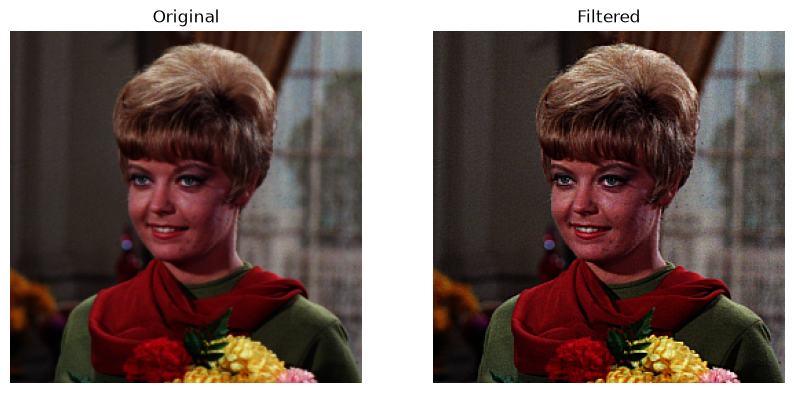

In [11]:
k = np.array([[0, 0, 0], [0, 2, 0], [0, 0, 0]], np.float32)
k = k - np.ones((3, 3), np.float32) / 9
image_filt = cv2.filter2D(image, -1, k)
fix, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image)
axs[0].set_title("Original")
axs[0].axis("off")
axs[1].imshow(image_filt)
axs[1].set_title("Filtered")
axs[1].axis("off")
plt.show()

### Other examples

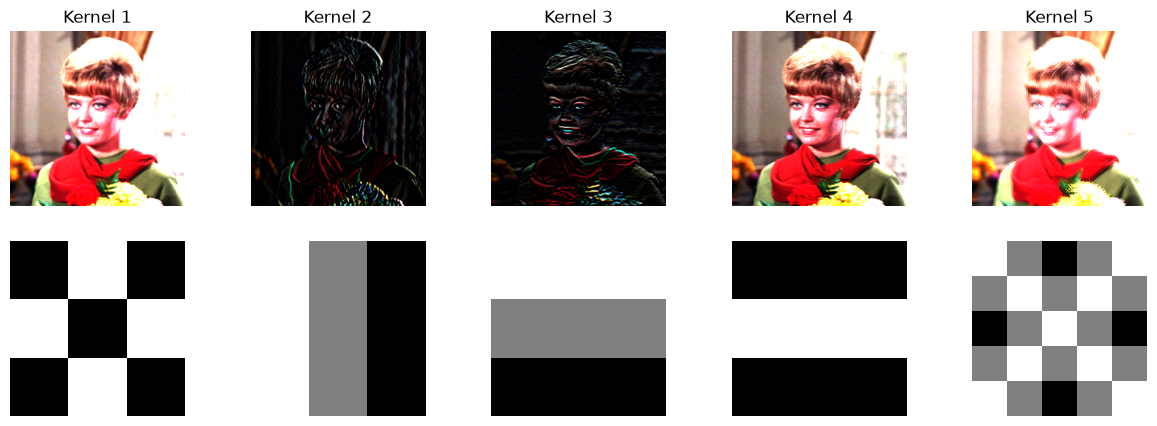

In [5]:
kernels = [
    np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]]),
    np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]]),
    np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]]),
    np.array([[0, 0, 0], [1, 1, 1], [0, 0, 0]]),
    np.array([[1, 0, -1, 0, 1], [0, 1, 0, 1, 0], [-1, 0, 1, 0, -1], [0, 1, 0, 1, 0], [1, 0, -1, 0, 1]]),
]
for kernel in kernels:
    convolved_image = cv2.filter2D(image, -1, kernel)
fig, axes = plt.subplots(2, len(kernels), figsize=(15, 5))
for i, kernel in enumerate(kernels):
    convolved_image = cv2.filter2D(image, -1, kernel)
    axes[0, i].imshow(convolved_image)
    axes[0, i].set_title(f'Kernel {i + 1}')
    axes[0, i].axis('off')
    axes[1, i].imshow(kernel, cmap='gray')
    axes[1, i].axis('off')
plt.show()